# Customer Sales Analysis

`retail_lab.db`의 고객 및 주문 데이터를 SQL로 조회하고  
pandas를 이용해 고객별·지역별 주문 현황을 분석한다.

## 분석 질문

1. 주문을 한 고객은 누구인가?
2. 고객별 주문 건수는 몇 건인가?
3. 지역별 주문 건수는 몇 건인가?
4. 주문이 없는 고객은 누구인가?
5. 주문 상태별 건수는 어떻게 구성되어 있는가?

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 현재 노트북 위치:
# D:\Study\Projects\00_foundation_review\notebooks

project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = study_root / "SQL" / "database" / "retail_lab.db"
output_dir = project_root / "outputs"

print("프로젝트 경로:", project_root)
print("데이터베이스 경로:", db_path)
print("출력 폴더:", output_dir)
print("DB 존재 여부:", db_path.exists())

프로젝트 경로: d:\Study\Projects\00_foundation_review
데이터베이스 경로: d:\Study\SQL\database\retail_lab.db
출력 폴더: d:\Study\Projects\00_foundation_review\outputs
DB 존재 여부: True


In [3]:
conn = sqlite3.connect(db_path)
print("데이터베이스 연결 완료")

데이터베이스 연결 완료


In [4]:
table_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
"""

tables_df = pd.read_sql(table_query, conn)

tables_df

,name
0,customers
1,orders
2,products


In [5]:
# 고객과 주문 JOIN
customer_sales_query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade,
    o.order_id,
    o.order_date,
    o.status
FROM customers AS c
INNER JOIN orders AS o
    ON c.customer_id = o.customer_id
ORDER BY o.order_date, o.order_id
"""

customer_sales_df = pd.read_sql(
    customer_sales_query,
    conn
)

customer_sales_df

,customer_id,customer_name,region,grade,order_id,order_date,status
0,1,Kim,Seoul,VIP,101,2026-07-20,paid
1,2,Lee,Busan,BASIC,102,2026-07-21,paid
2,1,Kim,Seoul,VIP,103,2026-07-22,paid
3,3,Park,Seoul,GOLD,104,2026-07-23,cancelled


In [6]:
# 데이터 기본 확인
print("행 수와 열 수:", customer_sales_df.shape)

print("\n컬럼 정보")
customer_sales_df.info()

print("\n결측치 개수")
print(customer_sales_df.isna().sum())

행 수와 열 수: (4, 7)

컬럼 정보
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    4 non-null      int64
 1   customer_name  4 non-null      str  
 2   region         4 non-null      str  
 3   grade          4 non-null      str  
 4   order_id       4 non-null      int64
 5   order_date     4 non-null      str  
 6   status         4 non-null      str  
dtypes: int64(2), str(5)
memory usage: 356.0 bytes

결측치 개수
customer_id      0
customer_name    0
region           0
grade            0
order_id         0
order_date       0
status           0
dtype: int64


In [7]:
# 날짜 자료형 변환
customer_sales_df["order_date"] = pd.to_datetime(
    customer_sales_df["order_date"]
)

customer_sales_df.dtypes

customer_id               int64
customer_name               str
region                      str
grade                       str
order_id                  int64
order_date       datetime64[us]
status                      str
dtype: object

In [8]:
# 고객별 주문 건수
customer_order_query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade,
    COUNT(o.order_id) AS order_count
FROM customers AS c
LEFT JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade
ORDER BY
    order_count DESC,
    c.customer_id
"""

customer_order_df = pd.read_sql(
    customer_order_query,
    conn
)

customer_order_df

,customer_id,customer_name,region,grade,order_count
0,1,Kim,Seoul,VIP,2
1,2,Lee,Busan,BASIC,1
2,3,Park,Seoul,GOLD,1
3,4,Choi,Incheon,BASIC,0


In [9]:
# 주문이 없는 고객 찾기
no_order_query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade
FROM customers AS c
LEFT JOIN orders AS o
    ON c.customer_id = o.customer_id
WHERE o.order_id IS NULL
ORDER BY c.customer_id
"""

no_order_df = pd.read_sql(
    no_order_query,
    conn
)

no_order_df

,customer_id,customer_name,region,grade
0,4,Choi,Incheon,BASIC


In [10]:
# 지역별 주문 건수
region_order_query = """
SELECT
    c.region,
    COUNT(o.order_id) AS order_count
FROM customers AS c
INNER JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY c.region
ORDER BY order_count DESC
"""

region_order_df = pd.read_sql(
    region_order_query,
    conn
)

region_order_df

,region,order_count
0,Seoul,3
1,Busan,1


In [11]:
# 주문 상태별 건수
status_order_query = """
SELECT
    status,
    COUNT(*) AS order_count
FROM orders
GROUP BY status
ORDER BY order_count DESC
"""

status_order_df = pd.read_sql(
    status_order_query,
    conn
)

status_order_df

,status,order_count
0,paid,3
1,cancelled,1


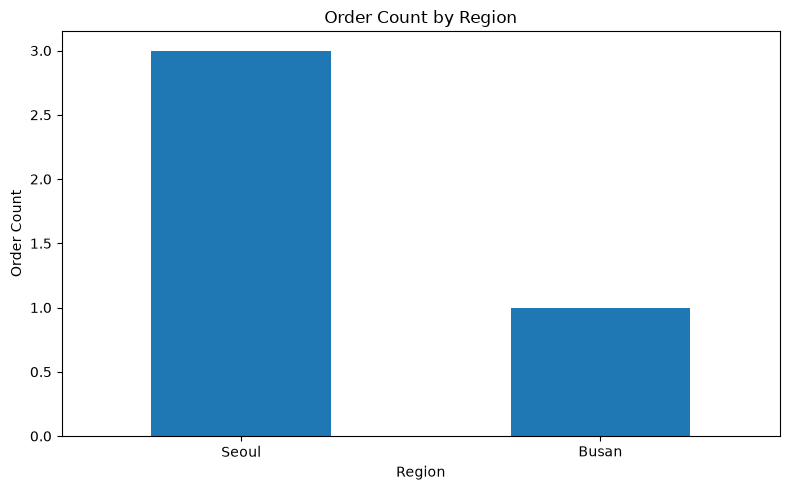

In [12]:
# 지역별 주문 건수 시각화
ax = region_order_df.plot.bar(
    x="region",
    y="order_count",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Order Count by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Order Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# customer_sales.csv 저장
csv_path = output_dir / "customer_sales.csv"

customer_sales_df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("CSV 저장 완료")
print(csv_path)

CSV 저장 완료
d:\Study\Projects\00_foundation_review\outputs\customer_sales.csv


In [14]:
# 저장된 csv 확인
saved_df = pd.read_csv(
    csv_path,
    encoding="utf-8-sig"
)

saved_df

,customer_id,customer_name,region,grade,order_id,order_date,status
0,1,Kim,Seoul,VIP,101,2026-07-20,paid
1,2,Lee,Busan,BASIC,102,2026-07-21,paid
2,1,Kim,Seoul,VIP,103,2026-07-22,paid
3,3,Park,Seoul,GOLD,104,2026-07-23,cancelled


In [15]:
# 데이터베이스 연결 종료
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료


## 분석 결과

- 전체 주문은 4건이다.
- Kim 고객의 주문 건수가 2건으로 가장 많다.
- Seoul 지역의 주문 건수가 가장 많다.
- 주문 상태는 paid 3건, cancelled 1건이다.
- Choi 고객은 주문 내역이 없다.

## 해석 시 주의점

현재 데이터는 학습용 소규모 표본이므로 실제 고객 행동을 일반화할 수 없다.  
현재 DB에는 주문과 상품을 연결하는 `product_id` 또는 `order_items` 테이블이 없기 때문에 상품별 판매량과 매출액은 분석할 수 없다.